# Work in progress: Batched LLM inference


**Note:** This notebook is a work in progress.

* It builds off the LLM fine-tuning tutorial: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial (read through this if you haven't yet)
* Model we built in the previous tutorial - https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1 

In [1]:
import time

print(f"Last updated: {time.ctime()}")

Last updated: Mon Apr 13 02:11:59 2026


## Overview

In the [Fine-tuning an LLM Tutorial](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial), we created [`FoodExtract-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1), a Small Language Model (SLM) designed to extract food and drink items from raw text.

We saw our model can perform quite well on individual samples.

However, what if we wanted to run our model on a large batch of samples?

For example, let's say we wanted to filter a dataset of 1 billion rows of image captions such as [`Recap-DataComp-1B`](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B) for the food and drink related items, if we wanted to make 1 billion predictions, this might take quite a while.

TK image - batched inference vs one by one inference

**Batched inference** is a method to speed this up.

Batched inference allows us to make predictions on multiple samples at a time.

For example, we pass our model 16 samples at a time instead of 1.

Because our model is on the smaller side (270M parameters total), we can leverage our hardware's ability to run it multiple times in one go.

We can then zip together our model's outputs with the input samples and inspect them later on.

Our goal in this tutorial will be to perform batched inference on our dataset with Hugging Face Transformers.

### Why perform batched inference?

The main goal of batched inference is for faster (higher throughput) predictions. Modern GPUs are often very good at parallelized computations. Therefore, predicting on multiple samples at a time is often much faster than one sample at a time.

Batched inference is often used in production workflows such as:

* Filtering a large dataset with a model.
* Replying to several users at a time with an LLM chat bot using the same model.

### Notes on batched inference

The number of samples you can predict on at once, known as the **batch size**, will depend on a few intertwined factors: 

* **The size of your model/available compute VRAM** - Model size and compute availability are intertwined. For example, your model has 7B parameters (~14GB memory footprint in float16 precision) but your GPU has 24GB of memory, your batch size might be limited to a lower number to account for memory bounds. Whereas, a model with a small number of parameters relative to the available GPU memory can often use a high batch size.
* **The size of your samples** - If one of your samples is 100x larger than other samples, this can negatively influence throughput. When performing batched inference, samples are often padded (bringing short sequences up to a certain length, often either the max length in a particular batch or a fixed value) or capped to be a certain size (for example, capping all sequences to a max of 512 total tokens, though this results in information loss). This uniformity of size (all tensors in the batch are the same size) takes advantage of GPU parallelism.

The optimal batch size for a particular hardware, model and data combination can be found experimentally.

To do so we can iterate through a number of different batches sizes and measure throughput speeds of each.

For example, we can experiment with batch sizes `1, 4, 8, 16, 32, 64, 128` (these are common values we can start with, powers of two are conventional starting points in the ML world and often work well in practice, however, our experiments are not bounded here, we could go larger or even choose a flat value like `100` if we wanted) and see which performs best.

:::{.callout-note}
A higher batch size generally results in a higher throughput of samples, however, this often levels out at a certain threshold.

For example, you might see a 4x speedup when going to batch size 16 (from batch size 1) but no speedup increases when going from batch size 16 to 64 (sometimes too large of a batch size can *degrade* performance).
:::

### Ingredients for batched inference

We'll need the following ingredients for our batched inference experiments:

* **Data** - Our target dataset will contain the samples we'll be performing batched inference on, we'll use the test samples from the [`FoodExtract-1k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.
* **Model** - We'll use the [`FoodExtract-v1`](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) model (a fine-tuned version of Gemma 3 270M). 
* **Hardware** - This is flexible. For me, I could run this on my local NVIDIA DGX Spark or NVIDIA RTX 4090 GPU. However, it will also work well on GPUs provided by Google Colab. For more on running this locally, see the [setup guide](https://www.learnhuggingface.com/extras/setup).
* **Software** - For this notebook, we'll be using Hugging Face Transformers and its built-in offerings. For a future tutorial, we'd likely look into a dedicated inference engine such as [vLLM](https://github.com/vllm-project/vllm) or [SGLang](https://github.com/sgl-project/sglang). See the [*Inference with vLLM*](https://www.learnhuggingface.com/notebooks/hugging_face_llm_inference_with_vllm) notebook for more.

We'll start by downloading the target dataset and model and then we'll write the experimentation code for measuring batched inference speed.


## TK - Load Dataset

TK - UPTOHERE: load the dataset, load the model, go from there

In [4]:
from datasets import load_dataset

DATASET_ID = "mrdbourke/FoodExtract-1k"

print(f"[INFO] Loading dataset: {DATASET_ID}")
dataset = load_dataset(DATASET_ID)

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

[INFO] Loading dataset: mrdbourke/FoodExtract-1k
[INFO] Number of samples in the dataset: 1420


In [5]:
import random
random_sample = random.choice(dataset['train'])
random_sample

{'sequence': 'A close-up image of a high-protein, dairy protein banana coffee-flavored yogurt package. The product is gluten-free and contains no added sugar. It provides 15g of protein per serving and has 98 calories with 0.6g of fat. The nutrition information panel shows the following details per serving (150g):\n\n- Energy: 411 kJ (98 Cal)\n- Protein: 15.1g\n- Fat: 0.6g (saturated: 0.4g)\n- Carbohydrate: 7.5g (sugars: 6.4g)\n- Dietary fiber: 0.0g\n- Sodium: 0.0g\n- Calcium: 67mg (20% RDI)\n- Gluten: NIL\n\nThe ingredients include skim milk, milk solids, water, thickener, butter, flavors, lemon pulp, natural color, stabilizer, and live cultures. The product is made by Lactalis Australia Pty Ltd and distributed by Kaiser Foods Singapore. The best before date is 20/10/25. The packaging also features a "Made in Australia" label.',
 'image_url': None,
 'class_label': 'food',
 'source': 'manual_taken_images',
 'char_len': 814.0,
 'word_count': 121.0,
 'syn_or_real': 'syn',
 'uuid': '0dae1

In [6]:
# Create helper function to turn samples into prompt and completion pairs
def sample_to_prompt_completion(sample):
    """Helper function to convert an input sample to prompt-completion style."""
    return {
        "prompt": [
            {"role": "user", "content": sample["sequence"]}, # load the sequence from the dataset
        ],
        "completion": [
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]} # load the condensed label from the ground truth
        ]
    }

sample_to_prompt_completion(random_sample)

{'prompt': [{'role': 'user',
   'content': 'A close-up image of a high-protein, dairy protein banana coffee-flavored yogurt package. The product is gluten-free and contains no added sugar. It provides 15g of protein per serving and has 98 calories with 0.6g of fat. The nutrition information panel shows the following details per serving (150g):\n\n- Energy: 411 kJ (98 Cal)\n- Protein: 15.1g\n- Fat: 0.6g (saturated: 0.4g)\n- Carbohydrate: 7.5g (sugars: 6.4g)\n- Dietary fiber: 0.0g\n- Sodium: 0.0g\n- Calcium: 67mg (20% RDI)\n- Gluten: NIL\n\nThe ingredients include skim milk, milk solids, water, thickener, butter, flavors, lemon pulp, natural color, stabilizer, and live cultures. The product is made by Lactalis Australia Pty Ltd and distributed by Kaiser Foods Singapore. The best before date is 20/10/25. The packaging also features a "Made in Australia" label.'}],
 'completion': [{'role': 'assistant',
   'content': 'food_or_drink: 1\ntags: np, il, fi, fp\nfoods: banana coffee-flavored yog

In [7]:
# Map the helper function to the dataset
dataset = dataset.map(sample_to_prompt_completion,
                      batched=False)

dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

In [8]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2, 
                                            shuffle=False,
                                            seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

## TK - Load the model and tokenizer

Our model is hosted here: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1

For more details on how it was trained, see the small language model fine-tuning tutorial.

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

print(f"[INFO] Loading tokenizer and model from: {MODEL_ID}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=MODEL_ID)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_ID,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

print(f"[INFO] Tokenizer and model loaded from: {MODEL_ID}")

# Check our model
model

[INFO] Loading tokenizer and model from: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


[INFO] Tokenizer and model loaded from: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

In [11]:
# Turn our loaded model into a pipeline for easy handling of preprocessing
from transformers import pipeline

loaded_model_pipeline = pipeline(task="text-generation",
                                 model=model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


## Format the dataset with the chat template

* TK - we're going to perform batched inference on the test dataset, let's first format it with the prompt/chat template.
* TK - show before and after of the sample with/without the prompt

In [12]:
# Format the test dataset with the prompt template
test_dataset = dataset["test"]

def format_input_prompt(sample):
    """Helper function to add the tokenizer chat template to the input prompt."""
    formatted_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(sample["prompt"],
                                                                           tokenize=False,
                                                                           add_generation_prompt=True)
    return {"formatted_prompt": formatted_prompt}

test_dataset = test_dataset.map(format_input_prompt, batched=False)
test_dataset[42]

Map:   0%|          | 0/284 [00:00<?, ? examples/s]

{'sequence': "This image shows the back of a food package with detailed cooking instructions, ingredients, and nutrition information. The package is held in a person's hand, and the background includes a concrete floor and part of a shoe.\n\n**Cooking Instructions:**\n- Ingredients listed include 1 cup snow peas, 1/2 cup frozen edamame, 2 cloves garlic, 2cm piece ginger, 1/4 cup stock of choice, 180g udon noodles, 3 spring onions, and 2 tablespoons sesame seeds.\n- Instructions mention cooking snow peas and edamame, adding oil, garlic, ginger, and stock, and then adding cooked udon noodles and tossing with protein, sesame seeds, and spring onions.\n\n**Nutrition Information:**\n- Servings per pack: 4\n- Serving size: 44g\n- Energy: 88kJ (21kcal) per serve, 201kJ (48kcal) per 100g\n- Protein: 0.4g per serve, 0.9g per 100g\n- Fat, Total: 0.6g per serve, 1.4g per 100g\n- Saturated Fat: 0.1g per serve, 0.3g per 100g\n- Carbohydrate: 3.4g per serve, 7.8g per 100g\n- Sugars: 1.1g per serve, 

### Run the model on a random sample from the test dataset

In [20]:
# TK - Run the model on a random sample
random_test_sample = random.choice(test_dataset)

random_sample_input_prompt_formatted = loaded_model_pipeline.tokenizer.apply_chat_template(random_test_sample["prompt"],
                                                                                           tokenize=False,
                                                                                           add_generation_prompt=True)    

random_sample_generated_output = loaded_model_pipeline(random_sample_input_prompt_formatted,
                                                       max_new_tokens=256,
                                                       disable_compile=True,
                                                       return_full_text=False) # only return the generated text, not the full prompt + generated

print(f"[INFO] Random test set sample input:\n{random_test_sample['prompt']}\n")
print(f"[INFO] Random test set sample formatted with chat template input:\n{random_test_sample['formatted_prompt']}")
print(f"[INFO] Random test sample ground truth:\n{random_test_sample['gpt-oss-120b-label-condensed']}\n")
print(f"[INFO] Model generated output:\n{random_sample_generated_output[0]['generated_text']}")

[INFO] Random test set sample input:
[{'content': 'Oreo Dunked in Cadbury Chocolate Original with Vanilla Flavoured Creme. Nutrition information: Energy 694 kJ, Protein 2.1 g, Fat Total 7.7 g, Saturated 4.5 g, Carbohydrate 21.7 g, Sugars 15.7 g, Sodium 95 mg. Ingredients: Sugar, Wheat Flour, Milk Solids, Vegetable Oils, Cocoa Mass, Cocoa Butter, Cocoa Powder, Glucose Syrup, Emulsifiers (442, 476), Soy Lecithin, Sunflower Lecithin, Cornstarch, Iodised Salt, Raising Agents (500, 503), Flavours, Antioxidants (307b, 304, 321, 320). Contains Wheat, Gluten, Milk, Soy. Milk Chocolate contains Cocoa Solids 20%, Milk Solids 28%.', 'role': 'user'}]

[INFO] Random test set sample formatted with chat template input:
<bos><start_of_turn>user
Oreo Dunked in Cadbury Chocolate Original with Vanilla Flavoured Creme. Nutrition information: Energy 694 kJ, Protein 2.1 g, Fat Total 7.7 g, Saturated 4.5 g, Carbohydrate 21.7 g, Sugars 15.7 g, Sodium 95 mg. Ingredients: Sugar, Wheat Flour, Milk Solids, Vegeta

## TK - Running batched inference three different ways

We do manual batching to allow customization to the samples within the inference steps.

TK - three approaches - turn this into a table:
1. Manual = full control but potentially error prone
2. Pipeline = automated but requires the input to be materialized as a list
3. KeyDataset = works directly with the dataset (good for larger datasets)

### TK - Running batched inference with manual batching

In [ ]:
import time 
from tqdm.auto import tqdm

all_outputs_manual = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
VERBOSE = False

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"\n[INFO] Running inference with batch size: {BATCH_SIZE}")
    start_time = time.time()
    
    batched_outputs_list = []
    for batch_num in tqdm(range(round(len(test_dataset) / BATCH_SIZE)), desc=f"Batch size {BATCH_SIZE}"):

        # Calculate the target index numbers of the dataset to select for the current batch
        # Add a check to ensure we don't go out of bound of the dataset length
        idxs_to_select = [i for i in list(range(BATCH_SIZE * batch_num, BATCH_SIZE * (batch_num + 1))) if i < len(test_dataset)]
        if VERBOSE:
            print(f"[INFO] Working on indexes: {idxs_to_select}")

        # Select indexes from the dataset and extract the formatted prompts for the current batch
        batched_inputs = test_dataset.select(idxs_to_select)
        batched_formatted_prompts = [item["formatted_prompt"] for item in batched_inputs]

        # Perform inference with pipeline on a list of input prompts and store the outputs
        batched_outputs = loaded_model_pipeline(batched_formatted_prompts,
                                                batch_size=BATCH_SIZE,
                                                max_new_tokens=256,
                                                disable_compile=True,
                                                return_full_text=False) # only return the generated text, not the full prompt + generated text
        
        # Add the outputs for the current batch to the list of inputs (so we can compare the generated outputs with the inputs later on if we want)
        batched_inputs_list = list(batched_inputs)
        for i in range(len(batched_outputs)):
            batched_inputs_list[i]["generated_text"] = batched_outputs[i][0]["generated_text"]

        # Extend the list of outputs
        batched_outputs_list.extend(batched_inputs_list)
    
    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_dataset)

    # Append the outputs and total time for the current batch to our results dictionary
    all_outputs_manual[BATCH_SIZE] = {"batched_outputs_list": batched_outputs_list, 
                                      "total_time": total_time,
                                      "avg_time_per_sample": avg_time_per_sample}

    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80)


[INFO] Running inference with batch size: 1


Batch size 1:   0%|          | 0/284 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[INFO] Total inference time for batch size 1: 141.91 seconds
[INFO] Average inference time per sample for batch size 1: 0.50 seconds



[INFO] Running inference with batch size: 4


Batch size 4:   0%|          | 0/71 [00:00<?, ?it/s]

...

[INFO] Total inference time for batch size 32: 28.35 seconds
[INFO] Average inference time per sample for batch size 32: 0.10 seconds



[INFO] Running inference with batch size: 64


Batch size 64:   0%|          | 0/4 [00:00<?, ?it/s]

[INFO] Total inference time for batch size 64: 30.42 seconds
[INFO] Average inference time per sample for batch size 64: 0.11 seconds



[INFO] Running inference with batch size: 128


Batch size 128:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Total inference time for batch size 128: 40.09 seconds
[INFO] Average inference time per sample for batch size 128: 0.14 seconds




In [23]:
for key, value in all_outputs_manual.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

Batch size: 1 | Total inference time: 141.91 seconds | Total samples: 284 | Average time per sample: 0.50 seconds
Batch size: 4 | Total inference time: 52.87 seconds | Total samples: 284 | Average time per sample: 0.19 seconds
Batch size: 8 | Total inference time: 34.80 seconds | Total samples: 284 | Average time per sample: 0.12 seconds
Batch size: 16 | Total inference time: 27.27 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 32 | Total inference time: 28.35 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 64 | Total inference time: 30.42 seconds | Total samples: 256 | Average time per sample: 0.11 seconds
Batch size: 128 | Total inference time: 40.09 seconds | Total samples: 256 | Average time per sample: 0.14 seconds


### TK - Running batched inference with automatic batching using pipeline

Automatic batching is the simplest option. But it requires our inputs to be materialized to a list (this can cause memory issues if our dataset is large).


In [24]:
import time

all_outputs_pipeline = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
VERBOSE = False

# Turn our input prompts into a list for the pipeline
test_input_prompts = list(test_dataset["formatted_prompt"])
print(f"[INFO] Total number of samples to run through the pipeline: {len(test_input_prompts)}")

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"[INFO] Running inference with batch size: {BATCH_SIZE}")
    start_time = time.time()

    pipeline_outputs = loaded_model_pipeline(
        text_inputs=test_input_prompts,
        batch_size=BATCH_SIZE,
        max_new_tokens=256,
        return_full_text=False
    )
    print(f"[INFO] Total pipeline outputs: {len(pipeline_outputs)}")

    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_input_prompts)
    
    # Zip together outputs and inputs
    # pipeline_outputs is a list of dictionaries in the form [{"generated_text": "..."}, ...]
    batched_outputs_list = list(test_dataset)
    for i in range(len(test_input_prompts)):
        batched_outputs_list[i]["generated_text"] = pipeline_outputs[i][0]["generated_text"]

    # Make a check that the output is the same length as the test dataset
    assert len(batched_outputs_list) == len(test_dataset), f"Lengths of batched_output_list (len={len(batched_outputs_list)}) and test_dataset (len={len(test_dataset)}) don't line up"

    # Output statement of how we're going
    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80 + "\n\n")

    # Append results to the dictionary
    all_outputs_pipeline[BATCH_SIZE] = {"batched_outputs_list": batched_outputs_list, 
                                        "total_time": total_time,
                                        "avg_time_per_sample": avg_time_per_sample}


[INFO] Total number of samples to run through the pipeline: 284
[INFO] Running inference with batch size: 1
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 1: 141.73 seconds
[INFO] Average inference time per sample for batch size 1: 0.50 seconds


[INFO] Running inference with batch size: 4
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 4: 51.01 seconds
[INFO] Average inference time per sample for batch size 4: 0.18 seconds


[INFO] Running inference with batch size: 8
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 8: 32.24 seconds
[INFO] Average inference time per sample for batch size 8: 0.11 seconds


[INFO] Running inference with batch size: 16
[INFO] Total pipeline outputs: 284
[INFO] Total inference time for batch size 16: 29.51 seconds
[INFO] Average inference time per sample for batch size 16: 0.10 seconds


[INFO] Running inference with batch size: 32
[INFO] Total pipeline outputs: 284


In [25]:
for key, value in all_outputs_pipeline.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

Batch size: 1 | Total inference time: 141.73 seconds | Total samples: 284 | Average time per sample: 0.50 seconds
Batch size: 4 | Total inference time: 51.01 seconds | Total samples: 284 | Average time per sample: 0.18 seconds
Batch size: 8 | Total inference time: 32.24 seconds | Total samples: 284 | Average time per sample: 0.11 seconds
Batch size: 16 | Total inference time: 29.51 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 32 | Total inference time: 27.10 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 64 | Total inference time: 26.37 seconds | Total samples: 284 | Average time per sample: 0.09 seconds
Batch size: 128 | Total inference time: 49.98 seconds | Total samples: 284 | Average time per sample: 0.18 seconds


### TK - Running batched inference with a KeyDataset

KeyDataset offers us the benefits of PyTorch's DataLoader behind the scenes and for working with larger datasets.

We don't have to turn our whole dataset into a list to iterate over it. 

We can lazily load batches of samples when we need to.

In [26]:
# Inspect our sample's keys (KeyDataset works on a target key in a dataset sample)
test_dataset[0]

{'sequence': 'Living Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.',
 'image_url': None,
 'class_label': 'food',
 'source': 'manual_taken_images',
 'char_len': 121.0,
 'word_count': 20.0,
 'syn_or_real': 'syn',
 'uuid': '27d52571-269f-413a-97b5-fb1af9b34adc',
 'gpt-oss-120b-label': "{'is_food_or_drink': True, 'tags': ['np', 'fi', 'di', 'fp', 'fa'], 'food_items': ['Living Planet Goat Milk Whole Milk'], 'drink_items': ['Living Planet Goat Milk Whole Milk']}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 1\ntags: np, fi, di, fp, fa\nfoods: Living Planet Goat Milk Whole Milk\ndrinks: Living Planet Goat Milk Whole Milk',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'Living Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.',
   'role': 'user'}],
 'completi

In [27]:
import time
from transformers.pipelines.pt_utils import KeyDataset

from tqdm.auto import tqdm

all_outputs_keydataset = {}

BATCH_SIZES_TO_TEST = [1, 4, 8, 16, 32, 64, 128] # customize these based on the size of your model and GPU memory
# BATCH_SIZES_TO_TEST = [32]
VERBOSE = False

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    print(f"[INFO] Running KeyDataset batched inference with batch size: {BATCH_SIZE}")
    start_time = time.time()

    keydataset_outputs = []
    for i, keydataset_output in enumerate(tqdm(
        loaded_model_pipeline(KeyDataset(test_dataset, "formatted_prompt"),
                              batch_size=BATCH_SIZE,
                              max_new_tokens=256,
                              return_full_text=False),
        total=len(test_dataset),
        desc=f"Batch size: {BATCH_SIZE}"
    )):
        test_sample = dict(test_dataset[i])
        test_sample["generated_text"] = keydataset_output[0]["generated_text"]
        keydataset_outputs.append(test_sample)

    print(f"[INFO] Total KeyDataset outputs: {len(keydataset_outputs)}")

    end_time = time.time()
    total_time = end_time - start_time
    avg_time_per_sample = total_time / len(test_dataset)

    # Make a check that the output is the same length as the test dataset
    assert len(keydataset_outputs) == len(test_dataset), f"Lengths of batched_output_list (len={len(batched_outputs_list)}) and test_dataset (len={len(test_dataset)}) don't line up"

    # Output statement of how we're going
    print(f"[INFO] Total inference time for batch size {BATCH_SIZE}: {total_time:.2f} seconds")
    print(f"[INFO] Average inference time per sample for batch size {BATCH_SIZE}: {avg_time_per_sample:.2f} seconds")
    print("="*80 + "\n")

    # Save artifacts to dictionary
    all_outputs_keydataset[BATCH_SIZE] = {"batched_outputs_list": keydataset_outputs,
                                          "total_time": total_time,
                                          "avg_time_per_sample": avg_time_per_sample}

[INFO] Running KeyDataset batched inference with batch size: 1


Batch size: 1:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 1: 142.03 seconds
[INFO] Average inference time per sample for batch size 1: 0.50 seconds


[INFO] Running KeyDataset batched inference with batch size: 4


Batch size: 4:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 4: 54.96 seconds
[INFO] Average inference time per sample for batch size 4: 0.19 seconds


[INFO] Running KeyDataset batched inference with batch size: 8


...

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 32: 32.73 seconds
[INFO] Average inference time per sample for batch size 32: 0.12 seconds


[INFO] Running KeyDataset batched inference with batch size: 64


Batch size: 64:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 64: 31.19 seconds
[INFO] Average inference time per sample for batch size 64: 0.11 seconds


[INFO] Running KeyDataset batched inference with batch size: 128


Batch size: 128:   0%|          | 0/284 [00:00<?, ?it/s]

[INFO] Total KeyDataset outputs: 284
[INFO] Total inference time for batch size 128: 46.22 seconds
[INFO] Average inference time per sample for batch size 128: 0.16 seconds




TK - extension/question/callout: how might this process work for a sample of 1M items? perhaps we'd like to implement checkpointing as well as sample saving (e.g. every 50k samples) so our list doesn't get too big

In [28]:
print(f"[INFO] Showing information for KeyDataset batched input inference:")
for key, value in all_outputs_keydataset.items():
    print(f"Batch size: {key} | Total inference time: {value['total_time']:.2f} seconds | Total samples: {len(value['batched_outputs_list'])} | Average time per sample: {value['avg_time_per_sample']:.2f} seconds")

[INFO] Showing information for KeyDataset batched input inference:
Batch size: 1 | Total inference time: 142.03 seconds | Total samples: 284 | Average time per sample: 0.50 seconds
Batch size: 4 | Total inference time: 54.96 seconds | Total samples: 284 | Average time per sample: 0.19 seconds
Batch size: 8 | Total inference time: 33.26 seconds | Total samples: 284 | Average time per sample: 0.12 seconds
Batch size: 16 | Total inference time: 28.22 seconds | Total samples: 284 | Average time per sample: 0.10 seconds
Batch size: 32 | Total inference time: 32.73 seconds | Total samples: 284 | Average time per sample: 0.12 seconds
Batch size: 64 | Total inference time: 31.19 seconds | Total samples: 284 | Average time per sample: 0.11 seconds
Batch size: 128 | Total inference time: 46.22 seconds | Total samples: 284 | Average time per sample: 0.16 seconds


## TK - Evaluating the outputs of our batches with SequenceMatcher

Let's create a simple evaluation function using Python's [`difflib.SequenceMatcher`](https://docs.python.org/3/library/difflib.html) to evaluate our model's outputs compared to the ground truth.

We'll also compare our model's outputs with a batch size of 1 (the baseline) with the outputs from using multiple items.

:::{.callout-note}
Due to the nature of how language models produce outputs, it's natural to see slight variations across different batch sizes.

For example, the outputs of our model for the same samples when running generations with batch size 8 may be slightly different to when running with batch size 1.

We'll run comparisons to make sure these differences aren't too great but it's worth knowing in practice.

For more on this (and how to reduce differences when running batched predictions), see the blog post *[Defeating Nondeterminism in LLM Inference](https://thinkingmachines.ai/blog/defeating-nondeterminism-in-llm-inference/) by Horace He* on Thinking Machines.
:::

We could also use a straight string comparison here too, for example, `string_1 == string_2`. 

But for now, we'll stick with a comparison that breaks sequences into tokens.

In [39]:
from difflib import SequenceMatcher

def get_text_similarity(text_a, text_b, verbose=False):
    """Simple text-level overlap: proportion of matching texts/tokens."""
    split_a = text_a.split()
    split_b = text_b.split()
    if verbose:
        print(f"Text a: {split_a}")
        print(f"Text b: {split_b}")
    matcher = SequenceMatcher(None, split_a, split_b)
    return matcher.ratio() # 0.0 to 1.0

text_a_example = "Hello my name is Daniel!"
text_b_example = "Hello my name is Sam!"
text_c_example = "Hello my name is Daniel."
text_d_example = "Hi my name is daniel!"
text_e_example = "dfhwrh208r32048y3208yh"

print(get_text_similarity(text_a=text_a_example, text_b=text_a_example))
print(get_text_similarity(text_a=text_a_example, text_b=text_b_example))
print(get_text_similarity(text_a=text_a_example, text_b=text_c_example))
print(get_text_similarity(text_a=text_a_example, text_b=text_d_example))
print(get_text_similarity(text_a=text_a_example, text_b=text_e_example))

1.0
0.8
0.8
0.6
0.0


TK - note: you can create more creative evals here, we are just doing simple matching

In [40]:
all_outputs_keydataset.keys()

dict_keys([1, 4, 8, 16, 32, 64, 128])

### TK - Getting baseline results for batch size 1

TK - batch size 1 will be our baseline we'd like to compare things to

In [41]:
baseline_results = all_outputs_keydataset[1]
baseline_total_time = baseline_results["total_time"]
baseline_avg_time_per_sample = baseline_results["avg_time_per_sample"]

def filter_generated_text(sample):
    prompt, generated_text = sample["formatted_prompt"], sample["generated_text"]
    if prompt in generated_text:
        return generated_text.replace(prompt, "")
    else:
        return generated_text

baseline_generated_texts = [filter_generated_text(sample) for sample in baseline_results["batched_outputs_list"]]
baseline_ground_truths = [sample["gpt-oss-120b-label-condensed"] for sample in baseline_results["batched_outputs_list"]]

In [42]:
baseline_sample = baseline_results["batched_outputs_list"][42]
baseline_sample

{'sequence': "This image shows the back of a food package with detailed cooking instructions, ingredients, and nutrition information. The package is held in a person's hand, and the background includes a concrete floor and part of a shoe.\n\n**Cooking Instructions:**\n- Ingredients listed include 1 cup snow peas, 1/2 cup frozen edamame, 2 cloves garlic, 2cm piece ginger, 1/4 cup stock of choice, 180g udon noodles, 3 spring onions, and 2 tablespoons sesame seeds.\n- Instructions mention cooking snow peas and edamame, adding oil, garlic, ginger, and stock, and then adding cooked udon noodles and tossing with protein, sesame seeds, and spring onions.\n\n**Nutrition Information:**\n- Servings per pack: 4\n- Serving size: 44g\n- Energy: 88kJ (21kcal) per serve, 201kJ (48kcal) per 100g\n- Protein: 0.4g per serve, 0.9g per 100g\n- Fat, Total: 0.6g per serve, 1.4g per 100g\n- Saturated Fat: 0.1g per serve, 0.3g per 100g\n- Carbohydrate: 3.4g per serve, 7.8g per 100g\n- Sugars: 1.1g per serve, 

In [43]:
filter_generated_text(baseline_sample)

'food_or_drink: 1\ntags: np, il, fi, fp\nfoods: snow peas, edamame, garlic, ginger, stock of choice, udon noodles, spring onions, sesame seeds, oil, garlic, ginger, stock of choice, Xanthan gum, Steviol glycosides, Spice Extract, Water, Soy Sauce (Water, Soybeans, Salt), Corn Starch, Vinegar, Fruit Juice Concentrate, Salt, Sesame Oil, Natural Colour (Caramel I), Onion, Garlic, Ginger, Sesame Seeds, Thickener (Xanthan gum), Xanthan gum, Natural Sweetener (Steviol glycosides), Steviol glycosides, Spice Extract, Sesame, Soy\ndrinks:'

In [44]:
get_text_similarity(text_a=baseline_sample["gpt-oss-120b-label-condensed"],
                    text_b=filter_generated_text(baseline_sample))

0.7407407407407407

In [45]:
similarities = [
    get_text_similarity(text_a=ground_truth,
                       text_b=generated_text)
    for ground_truth, generated_text in zip(baseline_ground_truths, baseline_generated_texts)
]

avg_similarity_score = sum(similarities) / len(similarities) * 100
print(f"[INFO] Average similarity score for batch size 1 with ground truth: {avg_similarity_score:.2f}%")

[INFO] Average similarity score for batch size 1 with ground truth: 93.23%


In [46]:
print(f"[INFO] Baseline total time for batch size 1: {baseline_total_time:.2f}s")

[INFO] Baseline total time for batch size 1: 142.03s


In [47]:
all_outputs_keydataset[1].keys()

dict_keys(['batched_outputs_list', 'total_time', 'avg_time_per_sample'])

### Comparing similarity results across batch sizes

In [48]:
print(f"{'Batch Size':<12} {'Length Match':<14} {'Avg Token Sim (to bs=1)':<14} {'Avg Token Sim (to GT)':<14} {'Time (s)':<10} {'Speedup vs bs=1'}")
print("=" * 100)

for BATCH_SIZE in BATCH_SIZES_TO_TEST:
    target_outputs = all_outputs_keydataset[BATCH_SIZE]
    target_total_time = target_outputs["total_time"]
    target_generated_texts = [filter_generated_text(sample) for sample in target_outputs["batched_outputs_list"]]
    
    # Do each of the batch sizes have the same number of samples?
    len_match = len(baseline_generated_texts) == len(target_generated_texts)

    # Measure the similarities across batches (e.g. batch size 1 compared to batch size 4)
    similarity_scores_to_batch_size_1 = [
        get_text_similarity(text_a=baseline_text, text_b=target_text)
        for baseline_text, target_text in zip(baseline_generated_texts, target_generated_texts)
    ]
    avg_similarity_score_to_batch_size_1 = round(sum(similarity_scores_to_batch_size_1) / len(similarity_scores_to_batch_size_1) * 100, 2) 
    similarity_score_string_to_batch_size_1 = f"{avg_similarity_score_to_batch_size_1:.2f}%"

    # Measure the similarities from batch size N to the ground truth
    similarity_scores_to_ground_truth = [
        get_text_similarity(text_a=ground_truth_text, text_b=target_text)
        for ground_truth_text, target_text in zip(baseline_ground_truths, target_generated_texts)
    ]
    avg_similarity_score_to_ground_truth = round(sum(similarity_scores_to_ground_truth) / len(similarity_scores_to_ground_truth) * 100, 2)
    similarity_score_string_to_ground_truth = f"{avg_similarity_score_to_ground_truth:.2f}%"

    # Measure the speedup multipliers from higher batch size
    speedup = round(baseline_total_time / target_total_time, 2)

    print(f"{BATCH_SIZE:<12} {str(len_match):<14} {similarity_score_string_to_batch_size_1:<23} {similarity_score_string_to_ground_truth:<21} {target_total_time:<10.2f} {speedup:.2f}x")

Batch Size   Length Match   Avg Token Sim (to bs=1) Avg Token Sim (to GT) Time (s)   Speedup vs bs=1
1            True           100.00%                 93.23%                142.03     1.00x
4            True           95.54%                  92.73%                54.96      2.58x
8            True           96.27%                  92.86%                33.26      4.27x
16           True           95.79%                  92.88%                28.22      5.03x
32           True           95.39%                  92.77%                32.73      4.34x
64           True           95.25%                  92.83%                31.19      4.55x
128          True           95.50%                  92.71%                46.22      3.07x


TK - explore this data above and provide insights

## TK - Evaluating the speed of our model across different batch sizes

In [49]:
# Setup the data
print(all_outputs_keydataset.keys())
print(all_outputs_keydataset[1].keys())

dict_keys([1, 4, 8, 16, 32, 64, 128])
dict_keys(['batched_outputs_list', 'total_time', 'avg_time_per_sample'])


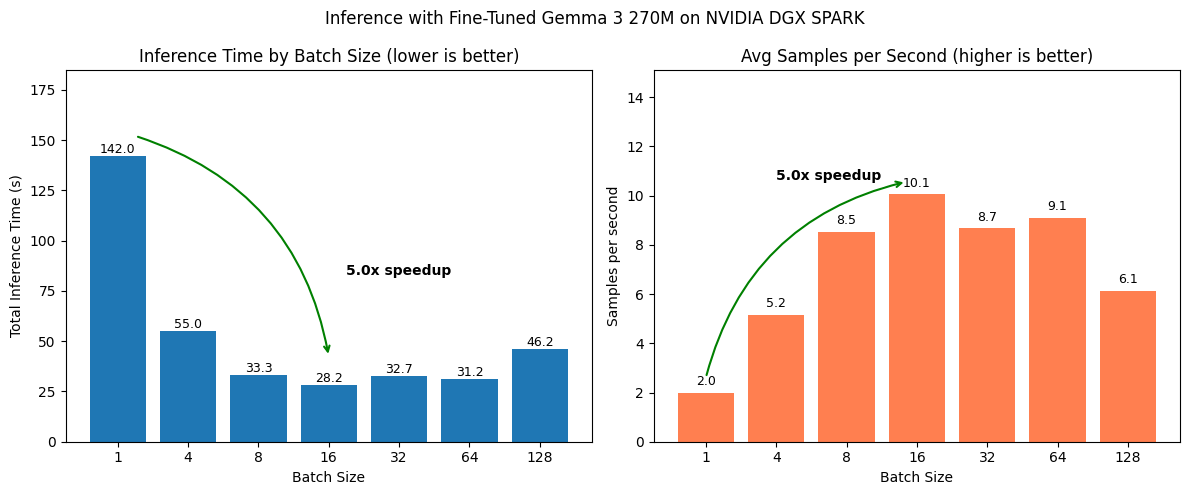

In [50]:
import matplotlib.pyplot as plt

total_samples = len(test_dataset)
all_inference_times = [all_outputs_keydataset[key]["total_time"] for key in all_outputs_keydataset.keys()]
all_samples_per_second = [total_samples / inference_time for inference_time in all_inference_times]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LEFT PLOT
# Total inference time per batch size
ax1.bar([str(batch_size) for batch_size in BATCH_SIZES_TO_TEST], all_inference_times)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Total Inference Time (s)")
ax1.set_title("Inference Time by Batch Size (lower is better)")
ax1.set_ylim(0, max(all_inference_times) * 1.3) # Increase headroom for text

# Add text to each column
for i, inference_time in enumerate(all_inference_times):
    ax1.text(i, inference_time + 1.5, f"{inference_time:.1f}", ha="center", fontsize=9)

# Add arrow to show speedup
# First let's get start (slowest) and end (fastest)
start_val_inference_time = max(all_inference_times)
end_val_inference_time = min(all_inference_times)
start_idx_inference_time = all_inference_times.index(start_val_inference_time)
end_idx_inference_time = all_inference_times.index(end_val_inference_time)

# Measure speedup
speedup_inference_time = start_val_inference_time / end_val_inference_time

# Draw the arrow from start (slowest) to end (fastest)
ax1.annotate("",
             xy=(end_idx_inference_time, end_val_inference_time + (0.5 * end_val_inference_time)), # Add a smaller buffer
             xytext=(start_idx_inference_time + 0.25, start_val_inference_time + 10),
             arrowprops=dict(arrowstyle="->", color="green", lw=1.5, connectionstyle="arc3,rad=-0.3"))

# Add text to arrow at the midpoint
mid_x_inference_time = ((start_idx_inference_time + end_idx_inference_time) / 2) + 1.75
text_y_inference_time = max(start_val_inference_time, end_val_inference_time) + (max(all_inference_times) * 0.1) - 75

ax1.text(x=mid_x_inference_time,
         y=text_y_inference_time,
         s=f"{speedup_inference_time:.1f}x speedup",
         va="bottom",
         fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

# RIGHT PLOT
# Samples per second
ax2.bar([str(batch_size) for batch_size in BATCH_SIZES_TO_TEST], all_samples_per_second, color="coral")
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Samples per second")
ax2.set_title("Avg Samples per Second (higher is better)")
ax2.set_ylim(0, max(all_samples_per_second) * 1.5) # Increase headroom for text

# Add text to each column
for i, samples_per_second in enumerate(all_samples_per_second):
    ax2.text(i, samples_per_second + 0.3, f"{samples_per_second:.1f}", ha="center", fontsize=9)

# Add arrow for right plot improvements
start_val_samples = min(all_samples_per_second)
end_val_samples = max(all_samples_per_second)
start_idx_samples = all_samples_per_second.index(start_val_samples)
end_idx_samples = all_samples_per_second.index(end_val_samples)

# Measure speedup
speedup_samples_per_second = round(end_val_samples / start_val_samples, 2)

# Draw the arrow from start (slowest) to end (fastest)
ax2.annotate("",
             xy=(end_idx_samples-(0.05 * end_idx_samples), end_val_samples + (0.05 * end_val_samples)),
             xytext=(start_idx_samples, start_val_samples + 0.6),
             arrowprops=dict(arrowstyle="->", color="green", lw=1.5, connectionstyle="arc3,rad=-0.3"))

# Place text at midpoint
mid_x_samples = ((start_idx_samples + end_idx_samples) / 2)
text_y_samples = (max(start_val_samples, end_val_samples) + (max(all_samples_per_second) * 0.1)) * 0.95

ax2.text(x=mid_x_samples-0.5, 
         y=text_y_samples,
         s=f"{speedup_samples_per_second:.1f}x speedup",
         va="bottom",
         fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

# Create a super title
DEVICE_NAME = "NVIDIA DGX SPARK"
plt.suptitle(f"Inference with Fine-Tuned Gemma 3 270M on {DEVICE_NAME}")
plt.tight_layout()

# Optional: Save the figure to file
# plt.savefig("transformers_llm_batched_inference_benchmark.png", dpi=150)

plt.show()

In [57]:
# Evaluate how many samples we could process per day
max_samples_per_second = round(max(all_samples_per_second), 2)
seconds_in_an_hour = 3600

samples_per_hour = seconds_in_an_hour * max_samples_per_second
samples_per_day = (seconds_in_an_hour * 24) * max_samples_per_second

print(f'[INFO] At a max speed of {max_samples_per_second} samples per second, this means we could process:\n\t{samples_per_hour} sampes per hour\n\t{samples_per_day} samples per day')

[INFO] At a max speed of 10.06 samples per second, this means we could process:
	36216.0 sampes per hour
	869184.0 samples per day


## TK - Extensions

We've seen a significant speedup after increasing the batch size we pass to our model.

Could we make things even faster?

* TK - next: vllm inference for faster language modelling 
* TK - next: evaluating models further

In [ ]:
# UPTOHERE: 
# Next:
# Go back through code, make sure it works ✅
# Add headings ✅
# Clean up code + explanations
# Start to explain what we're doing at each stage
# Prepare for recording  